## 11/7 ge calibration - DPR1-L-120-44

ge_freq = 8.02-0.00233 GHz

ge_pi_amp = 0.80


T1 = 15.260e-06/ 28.142e-06

T2 = 2.600e-06/ 6.206e-06

T2_star = 2.602e-06/ 2.490e-06

In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit

In [2]:
import sklearn
from sklearn.decomposition import PCA

In [3]:
def Rabi(delay, amp, phi0, detun, const):
    return - amp * np.cos(2*np.pi*detun*delay+phi0) + const

In [4]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [5]:
header = "D:/K_Sunada/result/CDY151/"

In [26]:
amp = "/2023-11-14/2023-11-14T113538_7f3106a5-21_ge_pi_amp"
dd_amp = datadict_from_hdf5(header + amp +"/data")

In [27]:
Rabi_amp = dd_amp['s11']['values']
imag_amp = Rabi_amp.imag
amp = dd_amp['amplitude']['values']

In [28]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2, pca

In [29]:
I_amp = (Rabi_amp.real)
Q_amp = (Rabi_amp.imag)
PCA_amp = PCA_transform(I_amp, Q_amp)


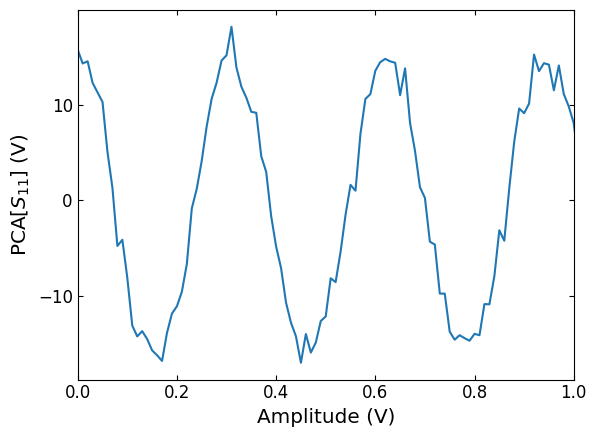

In [30]:
PCA_amp = PCA_transform(I_amp, Q_amp)
y = I_amp
x = amp

fig, (ax1) = plt.subplots(nrows=1)
ax1.set_xlabel('Amplitude (V)', size='large')
ax1.set_ylabel('PCA[$S_{11}$] (V)', size='large')
plt.rcParams["font.size"] = 17
plt.plot(x, PCA_amp[0])
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")
ax1.set_xlim(0, 1)
# ax1.set_ylim(-48, 160)
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )
plt.show()

In [31]:
par_ini= {
    'amp': 18,
    'phi0':np.pi,
    'detun':1/0.3,
    'const':0
}

par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [32]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
    
result = model.fit(data = PCA_amp[0], params = params, delay = x)
result

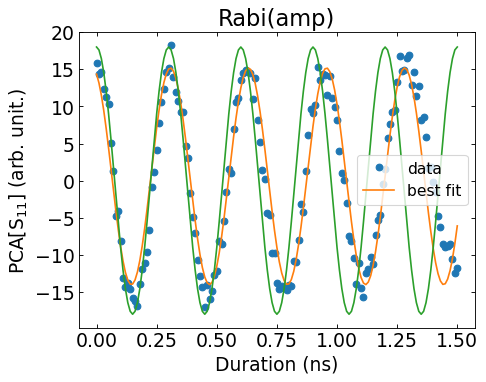

In [33]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(amp)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
plt.plot(x,result.init_fit)

plt.rcParams["font.size"] = 14
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

# plt.plot(x_t1,res1.init_fit, lult_tabel='init fit')

# ax.set_xlim(0, 250000)
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
ax.set_xlabel('Duration (ns)', size='large')
ax.set_ylabel('PCA[S$_{11}$] (arb. unit.)', size='large')

ax.legend()
plt.show()

In [34]:
np.pi/(3.08028970	*2*np.pi)*5

0.8116119727310065

ramsey

In [16]:
pl = "/2023-11-07/2023-11-07T222619_3c69983d-23_ge_T2r1d"
mi = "/2023-11-07/2023-11-07T222751_73a24b5f-23_ge_T2r1d"
dd_pl = datadict_from_hdf5(header + pl +"/data")
dd_mi = datadict_from_hdf5(header + mi +"/data")

In [17]:
Rabi_pl = dd_pl['s11']['values']
imag_pl = Rabi_pl.imag
delay_pl = dd_pl['delay']['values']

Rabi_mi = dd_mi['s11']['values']
imag_mi = Rabi_mi.imag
delay_mi = dd_mi['delay']['values']

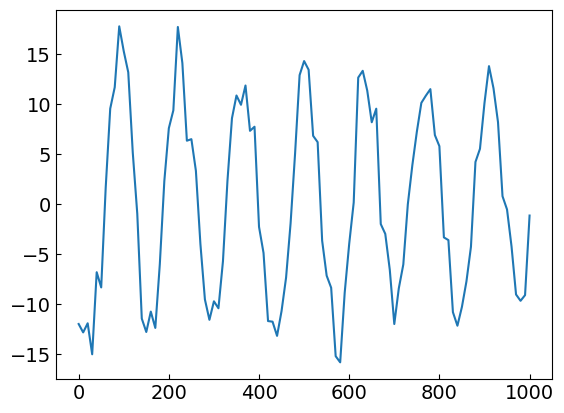

In [18]:
I_pl = (Rabi_pl.real)
Q_pl = (Rabi_pl.imag)
I_mi = (Rabi_mi.real)
Q_mi = (Rabi_mi.imag)


PCA_pl = PCA_transform(I_pl, Q_pl)
y_pl = PCA_pl[0]
x_pl = delay_pl

PCA_mi = PCA_transform(I_mi, Q_mi)
y_mi = PCA_mi[0]
x_mi = delay_mi



plt.plot(x_pl, y_pl)
plt.show()

In [38]:
par_ini_pl = {
    'amp': 13,
    'phi0':0,
    'detun':1/145,
    'const':0
}

par_min_pl = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max_pl = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary_pl = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [39]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_pl[name],
    min = par_min_pl[name],
    max = par_max_pl[name],
    vary = par_vary_pl[name]
    )
    
result_pl = model.fit(data = y_pl, params = params, delay = x_pl)
result_pl

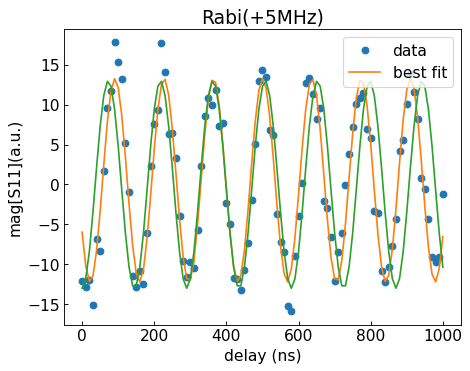

In [40]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(+5MHz)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_pl.plot_fit(ax = ax)
plt.plot(x_pl,result_pl.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")


plt.show()

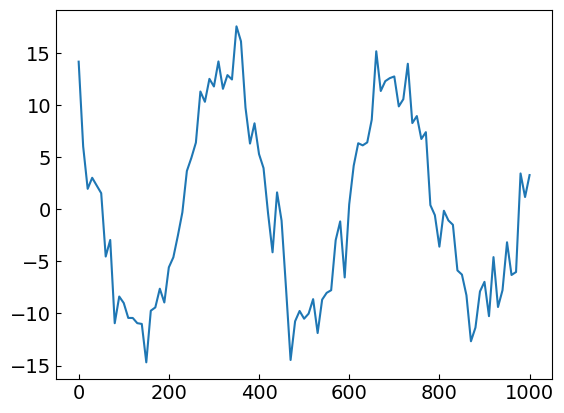

In [41]:
plt.plot(x_mi, y_mi)
plt.show()

In [42]:
par_ini_mi = {
    'amp': 13,
    'phi0':np.pi,
    'detun':1/350,
    'const':0
}

par_min_mi = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max_mi = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary_mi = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [43]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_mi[name],
    min = par_min_mi[name],
    max = par_max_mi[name],
    vary = par_vary_mi[name]
    )
    
result_mi = model.fit(data = y_mi, params = params, delay = x_mi)
result_mi

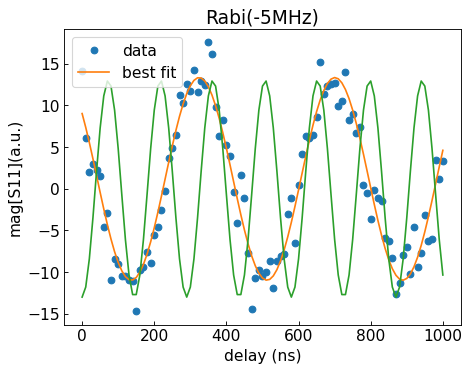

In [44]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(-5MHz)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_mi.plot_fit(ax = ax)
plt.plot(x_mi,result_pl.init_fit)

plt.xlabel("delay (ns)")
plt.ylabel("mag[S11](a.u.)")


plt.show()


In [45]:
detun = ((0.005-0.00732139)+ (0.00265696-0.005))/2 #GHz
detun

-0.002332215

drag

In [88]:
drag = "/2023-11-08/2023-11-08T132029_26896112-22_ge_pi_drag"
dd_drag = datadict_from_hdf5(header + drag +"/data")

drag1 = "/2023-11-08/2023-11-08T132207_609ce361-22_ge_pi_drag"
dd_drag1 = datadict_from_hdf5(header + drag1 +"/data")

drag2 = "/2023-11-08/2023-11-08T131849_eaa1e686-22_ge_pi_drag"
dd_drag2 = datadict_from_hdf5(header + drag2 +"/data")

In [89]:
Rabi_drag = dd_drag['s11']['values']
imag_drag = Rabi_drag.imag
drag = dd_drag['beta']['values']
I_drag = (Rabi_drag.real)
Q_drag = (Rabi_drag.imag)

Rabi_drag1 = dd_drag1['s11']['values']
imag_drag1 = Rabi_drag1.imag
drag1 = dd_drag1['beta']['values']
I_drag1 = (Rabi_drag1.real)
Q_drag1 = (Rabi_drag1.imag)

Rabi_drag2 = dd_drag2['s11']['values']
imag_drag2 = Rabi_drag2.imag
drag2 = dd_drag2['beta']['values']
I_drag2 = (Rabi_drag2.real)
Q_drag2 = (Rabi_drag2.imag)

In [90]:
def PCA_transform1(Re_c_amp, Im_c_amp, Re_c_drag, Im_c_drag):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c_amp]).T, np.array([Im_c_amp]).T], axis = 1)
    c1_data = np.concatenate([np.array([Re_c_drag]).T, np.array([Im_c_drag]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    
    c1_pca = pca.transform(c1_data)
    c1_PCA1 = c1_pca.T[0]
    c1_PCA2 = c1_pca.T[1]
    return c_PCA1, c_PCA2, c1_PCA1, c1_PCA2,

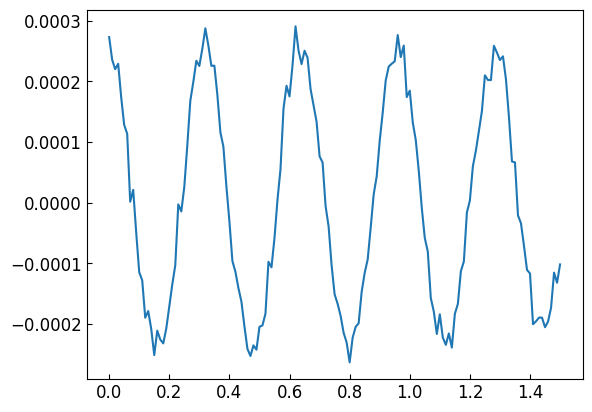

In [91]:
PCA_drag = PCA_transform1(I_amp, Q_amp, I_drag, Q_drag)
y = PCA_drag[0]
x = amp
y0 = PCA_drag[2]
x0 = drag

PCA_drag1 = PCA_transform1(I_amp, Q_amp, I_drag1, Q_drag1)
y1 = PCA_drag1[2]
x1 = drag1

PCA_drag2 = PCA_transform1(I_amp, Q_amp, I_drag2, Q_drag2)
y2 = PCA_drag2[2]
x2 = drag2


plt.plot(x, y)
plt.show()

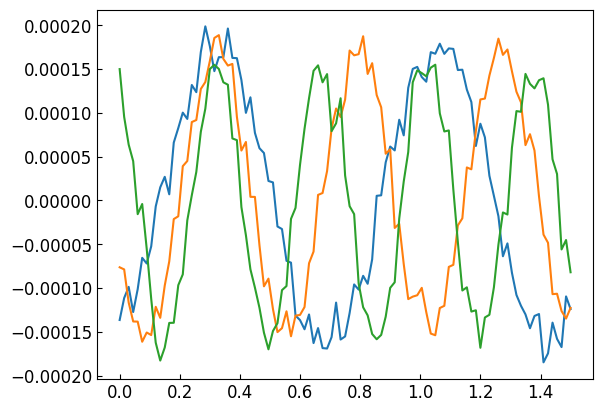

In [92]:
plt.plot(x0, y0)
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.show()

In [108]:
par_ini= {
    'amp': 0.0002,
    'phi0':np.pi,
    'detun':1/0.3,
    'const':0.
}

par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [109]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
    
result0 = model.fit(data = y0, params = params, delay = x0)
result1 = model.fit(data = y1, params = params, delay = x1)
result2 = model.fit(data = y2, params = params, delay = x2)

In [95]:
result0

In [99]:
res0 = (np.pi-0.38429259)/(2*np.pi*1.35950410)
res0

0.32279265263555507

In [102]:
result1

In [107]:
res1 = (np.pi+1.10024008)/(2*np.pi*2.10771289)
res1

0.3203038945782707

In [110]:
result2

In [112]:
res2 = (3*np.pi-3.62679977)/(2*np.pi*2.85409713)
res2

0.3233165680664662

In [113]:
beta = (res0 + res1 + res2)/3
beta

0.32213770509343065

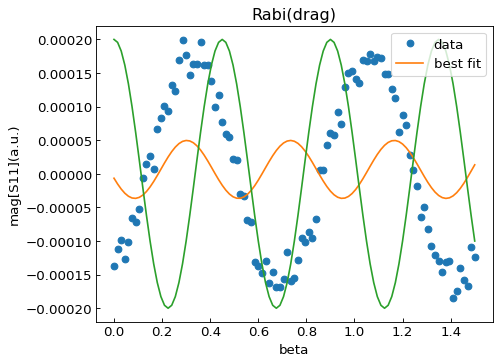

In [103]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result0.plot_fit(ax = ax)
plt.plot(x0,result0.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

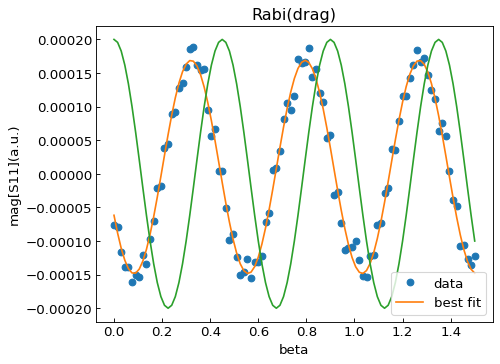

In [104]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result1.plot_fit(ax = ax)
plt.plot(x1,result1.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

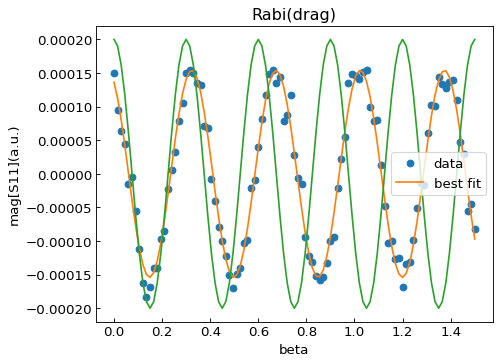

In [111]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result2.plot_fit(ax = ax)

plt.plot(x2,result2.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()


half drag

In [130]:
drag = "/2023-11-08/2023-11-08T131224_051bda6b-22_ge_pi_drag"
dd_drag = datadict_from_hdf5(header + drag +"/data")

drag1 = "/2023-11-08/2023-11-08T131423_4c73411e-22_ge_pi_drag"
dd_drag1 = datadict_from_hdf5(header + drag1 +"/data")

drag2 = "/2023-11-08/2023-11-08T134820_0a9b20c7-22_ge_pi_drag"
dd_drag2 = datadict_from_hdf5(header + drag2 +"/data")

In [131]:
Rabi_drag = dd_drag['s11']['values']
imag_drag = Rabi_drag.imag
drag = dd_drag['beta']['values']
I_drag = (Rabi_drag.real)
Q_drag = (Rabi_drag.imag)

Rabi_drag1 = dd_drag1['s11']['values']
imag_drag1 = Rabi_drag1.imag
drag1 = dd_drag1['beta']['values']
I_drag1 = (Rabi_drag1.real)
Q_drag1 = (Rabi_drag1.imag)

Rabi_drag2 = dd_drag2['s11']['values']
imag_drag2 = Rabi_drag2.imag
drag2 = dd_drag2['beta']['values']
I_drag2 = (Rabi_drag2.real)
Q_drag2 = (Rabi_drag2.imag)

In [132]:
def PCA_transform1(Re_c_amp, Im_c_amp, Re_c_drag, Im_c_drag):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c_amp]).T, np.array([Im_c_amp]).T], axis = 1)
    c1_data = np.concatenate([np.array([Re_c_drag]).T, np.array([Im_c_drag]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    
    c1_pca = pca.transform(c1_data)
    c1_PCA1 = c1_pca.T[0]
    c1_PCA2 = c1_pca.T[1]
    return c_PCA1, c_PCA2, c1_PCA1, c1_PCA2,

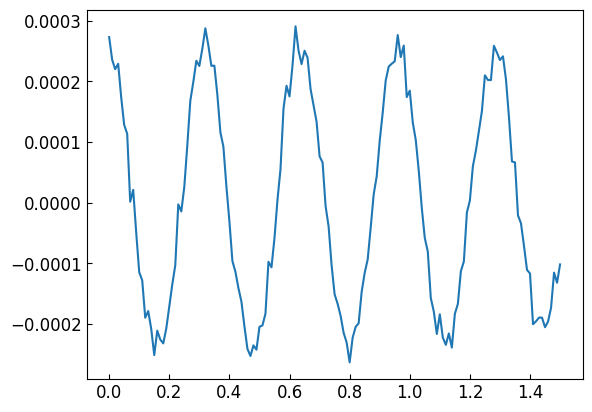

In [133]:
PCA_drag = PCA_transform1(I_amp, Q_amp, I_drag, Q_drag)
y = PCA_drag[0]
x = amp
y0 = PCA_drag[2]
x0 = drag

PCA_drag1 = PCA_transform1(I_amp, Q_amp, I_drag1, Q_drag1)
y1 = PCA_drag1[2]
x1 = drag1

PCA_drag2 = PCA_transform1(I_amp, Q_amp, I_drag2, Q_drag2)
y2 = PCA_drag2[2]
x2 = drag2


plt.plot(x, y)
plt.show()

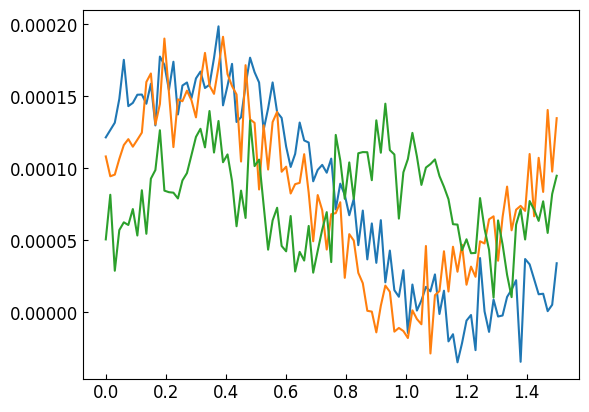

In [134]:
plt.plot(x0, y0)
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.show()

In [147]:
par_ini= {
    'amp': 0.00005,
    'phi0':np.pi,
    'detun':1/0.7,
    'const':0.00007
}

par_min = {
    'amp': 0,
    'phi0':-2*np.pi,
    'detun':-np.inf,
    'const':0
}

par_max = {
    'amp': np.inf,
    'phi0':2*np.pi,
    'detun':np.inf,
    'const':np.inf,
}

par_vary = {
    'amp': True,
    'phi0':True,
    'detun':True,
    'const':True
}

In [148]:
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
    
result0 = model.fit(data = y0, params = params, delay = x0)
result1 = model.fit(data = y1, params = params, delay = x1)
result2 = model.fit(data = y2, params = params, delay = x2)

In [137]:
result0

In [141]:
res0 = (np.pi-2.11557706)/(2*np.pi*0.53781687)
res0

0.30362649912633033

In [144]:
result1

In [146]:
res1 = (np.pi-1.75673117)/(2*np.pi*	0.70596698)
res1

0.31220660010315393

In [149]:
result2

In [151]:
res2 = (np.pi-0.10709969)/(2*np.pi*1.53223229)
res2

0.3151966957522415

In [152]:
beta = (res0 + res1 + res2)/3
beta

0.3103432649939086

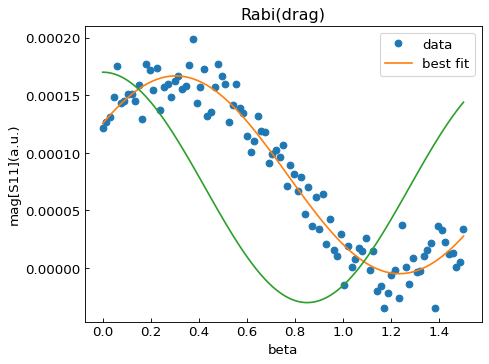

In [138]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result0.plot_fit(ax = ax)
plt.plot(x0,result0.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

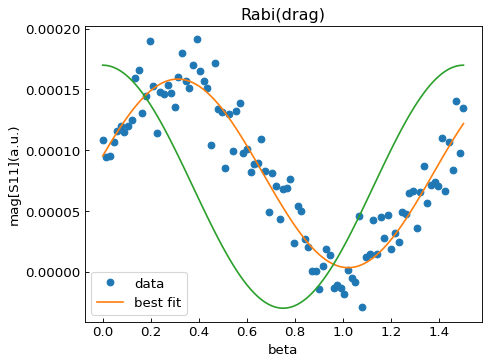

In [145]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result1.plot_fit(ax = ax)
plt.plot(x1,result1.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()

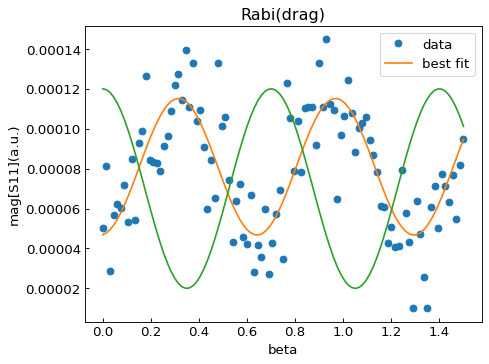

In [150]:
fig, ax = plt.subplots(dpi=80)

plt.title("Rabi(drag)")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result2.plot_fit(ax = ax)

plt.plot(x2,result2.init_fit)


plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")

plt.show()


T1

In [35]:
def Dephase(delay, amp, gamma, const):
    return amp*np.exp(-gamma*delay) + const

t1 ="/2023-11-14/2023-11-14T112105_768f9278-24_ge_T1"

dd_t1 = datadict_from_hdf5(header + t1 +"/data")

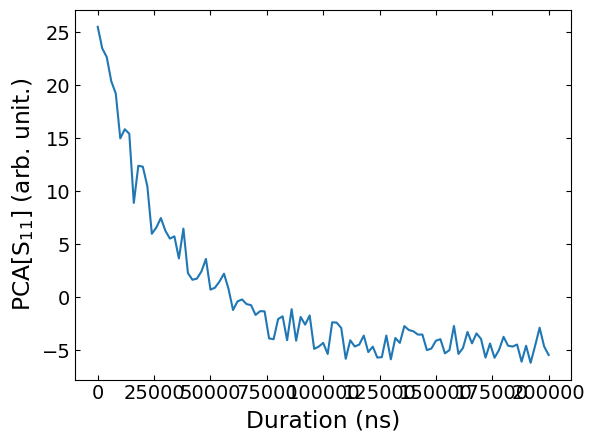

In [21]:
s11_t1 = dd_t1['s11']['values']#[0:247]
imag_t1 = s11_t1.imag
delay_t1 = dd_t1['delay']['values']#[0:247]

I_t1 = (s11_t1.real)
Q_t1 = (s11_t1.imag)
ang_t1 = np.angle(s11_t1)

PCA_t1 = PCA_transform(I_t1, Q_t1)

y_t1 = PCA_t1[0]
x_t1 = delay_t1

fig, (ax1) = plt.subplots(nrows=1)
ax1.set_xlabel('Delay (ns)', size='large')
ax1.set_ylabel('PCA[S$_{11}$] (arb. unit.)', size='large')
plt.rcParams["font.size"] = 10
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")
# ax1.set_xlim(0, 250000)
# ax1.set_ylim(-48, 160)
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

plt.plot(x_t1, y_t1)
plt.show()

In [22]:
par_ini_t1 = {
    'gamma': 1/40000,
    'amp':30,
    'const':0
}

par_min_t1 = {
    'gamma': 0,
    'amp':0,
    'const':-np.inf
}

par_max_t1 = {
    'gamma': np.inf,
    'amp':np.inf,
    'const':np.inf,
}

par_vary_t1 = {
    'gamma': True,
    'amp':True,
    'const':True
}

In [23]:
model = lmfit.Model(Dephase)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t1[name],
    min = par_min_t1[name],
    max = par_max_t1[name],
    vary = par_vary_t1[name]
    )
result_t1 = model.fit(data = y_t1, params = params, delay = x_t1)
result_t1

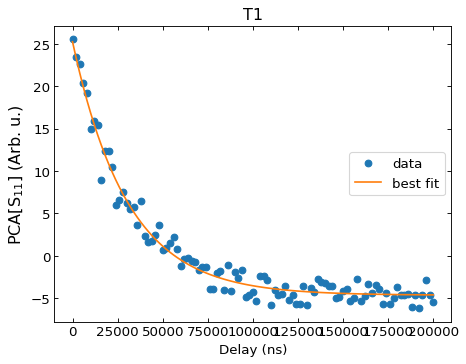

In [37]:
fig, (ax) = plt.subplots(dpi=80)
plt.title("T1")


plt.rcParams["font.size"] = 12
plt.tick_params(
            top='on',
            bottom='on',
            left='on',
            right='on',
            )

result_t1.plot_fit(ax = ax)
# plt.plot(x_t1,result_t1.init_fit, label='init fit')

# ax.set_ylim(-8, 15)
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
ax.set_xlabel('Delay (ns)')#, size='large')
ax.set_ylabel('PCA[S$_{11}$] (Arb. u.)', size='large')

plt.legend(loc=7)
plt.show()

In [25]:
T1 = (1/3.2832e-05)*1e-9	
T1

3.0458089668615986e-05

T2_star

In [70]:
t2e = "/2023-11-09/2023-11-09T180809_80a5a4b2-25_ge_T2e"
dd_t2e = datadict_from_hdf5(header + t2e +"/data")

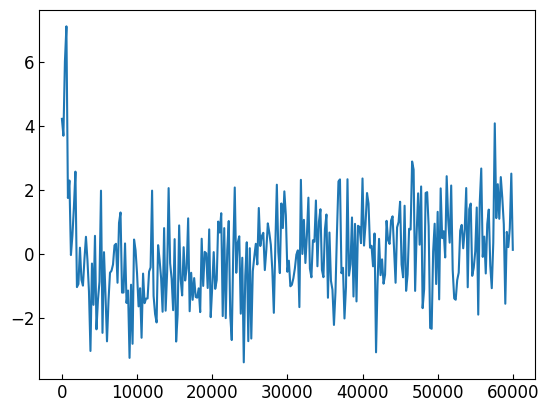

In [71]:
s11_t2e = dd_t2e['s11']['values']
imag_t2e = s11_t2e.imag
delay_t2e = dd_t2e['delay']['values']

I_t2e = (s11_t2e.real)
Q_t2e = (s11_t2e.imag)

PCA_t2e = PCA_transform(I_t2e, Q_t2e)

y_t2e = PCA_t2e[0]
x_t2e = delay_t2e

plt.plot(x_t2e, y_t2e)
plt.show()

In [43]:
par_ini_t2e = {
    'gamma': 1/15000,
    'amp':20,
    'const':0
}

par_min_t2e = {
    'gamma': 0,
    'amp':0,
    'const':-np.inf
}

par_max_t2e = {
    'gamma': np.inf,
    'amp':np.inf,
    'const':np.inf,
}

par_vary_t2e = {
    'gamma': True,
    'amp':True,
    'const':True
}

In [44]:
model = lmfit.Model(Dephase)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t2e[name],
    min = par_min_t2e[name],
    max = par_max_t2e[name],
    vary = par_vary_t2e[name]
    )
result_t2e = model.fit(data = y_t2e, params = params, delay = x_t2e)
result_t2e

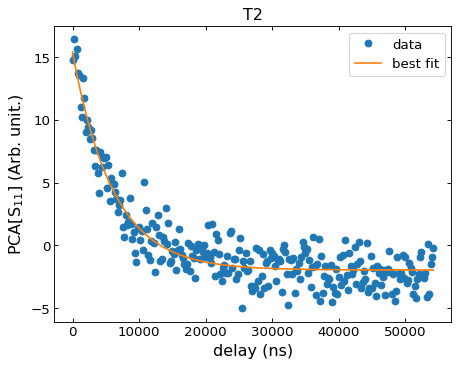

In [45]:
fig, ax = plt.subplots(dpi=80)

plt.title("T2")

plt.rcParams["font.size"] = 12
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

result_t2e.plot_fit(ax = ax)
# plt.plot(delay_t2e,result_t2e.init_fit)

# ax.set_ylim(-10, 35)
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
ax.set_xlabel('delay (ns)', size='large')
ax.set_ylabel('PCA[S$_{11}$] (Arb. unit.)', size='large')

# plt.legend(loc=7)
plt.show()

In [46]:
T2 = (1/	1.6502e-04)*1e-9	
T2

6.059871530723549e-06

T2 star

In [72]:
def Damping(delay, amp, gamma, omega, phi0, const):
    return const + amp * np.exp(- gamma*delay)*np.cos(omega*delay + phi0)

In [73]:
t2 = "/2023-11-09/2023-11-09T181240_22599ec3-23_ge_T2r1d"
dd_t2 = datadict_from_hdf5(header + t2 +"/data")

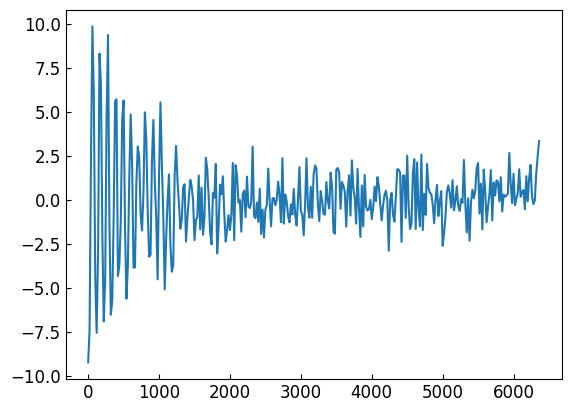

In [74]:
s11_t2 = dd_t2['s11']['values']
imag_t2 = s11_t2.imag
delay_t2 = dd_t2['delay']['values']

I_t2 = (s11_t2.real)
Q_t2 = (s11_t2.imag)

PCA_t2 = PCA_transform(I_t2, Q_t2)

y_t2 = PCA_t2[0]
x_t2 = delay_t2

plt.plot(x_t2, y_t2)
plt.show()

In [50]:
par_ini_t2 = {
    'amp':15,
    'gamma': 1/6000,
    'omega':2*np.pi/1000,
    'phi0':0,
    'const':0
}

par_min_t2 = {
    'amp':-np.inf,
    'gamma': 0,
    'omega':-2*np.pi,
    'phi0':-2*np.pi,
    'const':-np.inf
}

par_max_t2 = {
    'amp':np.inf,
    'gamma': np.inf,
    'omega':2*np.pi,
    'phi0':2*np.pi,
    'const':np.inf
}

par_vary_t2 = {
    'amp':True,
    'gamma': True,
    'omega':True,
    'phi0':True,
    'const':True
}

In [51]:
model = lmfit.Model(Damping)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t2[name],
    min = par_min_t2[name],
    max = par_max_t2[name],
    vary = par_vary_t2[name]
    )
result_t2 = model.fit(data = y_t2, params = params, delay = x_t2)
result_t2

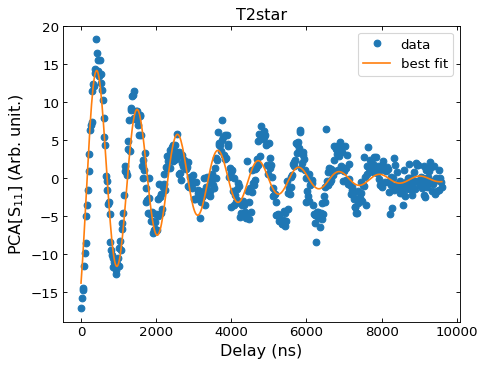

In [52]:
fig, ax = plt.subplots(dpi=80)

plt.title("T2star")

plt.rcParams["font.size"] = 12
plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

result_t2.plot_fit(ax = ax)
# plt.plot(delay_t2,result_t2.init_fit)


# ax.set_ylim(-10, 35)
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
ax.set_xlabel('Delay (ns)', size='large')
ax.set_ylabel('PCA[S$_{11}$] (Arb. unit.)', size='large')

plt.show()

In [53]:
T2_star = (1/4.1135e-04)*1e-9	
T2_star

2.4310198128114745e-06